**Turning Feedback into Insights- (Sentiment + TF-IDF Review Analyzer)**

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset/sentiment_dataset_120.csv')

In [33]:
df.shape

(120, 2)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     120 non-null    object
 1   sentiment  120 non-null    object
dtypes: object(2)
memory usage: 2.0+ KB


In [35]:
df.head(10)

,review,sentiment
0,"Fantastic purchase, will buy again 1",positive
1,Completely dissatisfied with the product,negative
2,"Really good product, exceeded expectations",positive
3,"Not as described, very bad",negative
4,"Superb experience, very satisfied 3",positive
5,Stopped working after a few days,negative
6,"Excellent quality, highly recommended",positive
7,"Not as described, very bad",negative
8,"Excellent quality, highly recommended",positive
9,"Terrible experience, do not buy",negative


In [36]:
df.isnull().sum()

,0
review,0
sentiment,0


**TF-IDF** -- I identified key drivers of positive and negative customer sentiment

In [37]:
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df['review'])

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)


**Keywords by Sentiment**

In [38]:
df_tfidf = pd.concat([df, tfidf_df], axis=1)

positive_words = df_tfidf[df_tfidf['sentiment'] == 'positive'].iloc[:, 2:].sum()
negative_words = df_tfidf[df_tfidf['sentiment'] == 'negative'].iloc[:, 2:].sum()

top_positive = positive_words.sort_values(ascending=False).head(10)
top_negative = negative_words.sort_values(ascending=False).head(10)

print("Top Positive Words:\n", top_positive)
print("\nTop Negative Words:\n", top_negative)

Top Positive Words:
 useful       13.769824
fantastic     5.948826
purchase      5.948826
buy           5.405825
amazing       4.822018
product       4.590178
quality       3.852251
works         3.662430
value         3.570864
great         3.570864
dtype: float64

Top Negative Words:
 bad              8.844713
described        8.044538
poor             6.338503
quality          5.371345
product          5.218939
worth            4.949747
disappointing    4.949747
broke            4.448877
quickly          4.448877
regret           4.430596
dtype: float64


**Print all Positive and Negative words**

In [46]:
print("Positive Words:\n",positive_words)
print("\nNegative Words:\n",negative_words)

Positive Words:
 amazing           4.822018
bad               0.000000
broke             0.000000
buy               5.405825
buying            0.000000
cheap             0.000000
completely        0.000000
days              0.000000
delivery          2.710960
described         0.000000
design            0.000000
disappointing     0.000000
dissatisfied      0.000000
exceeded          1.908878
excellent         3.237575
expectations      1.908878
expected          1.822262
experience        2.625149
fantastic         5.948826
fast              2.710960
good              1.908878
great             3.570864
happy             1.822262
high              2.710960
highly            3.237575
love              2.395569
low               0.000000
material          0.000000
money             3.240039
perfectly         2.395569
poor              0.000000
product           4.590178
purchase          5.948826
quality           3.852251
quickly           0.000000
really            1.908878
recommended

In [39]:
df.head()

,review,sentiment
0,"Fantastic purchase, will buy again 1",positive
1,Completely dissatisfied with the product,negative
2,"Really good product, exceeded expectations",positive
3,"Not as described, very bad",negative
4,"Superb experience, very satisfied 3",positive


**Visualization**

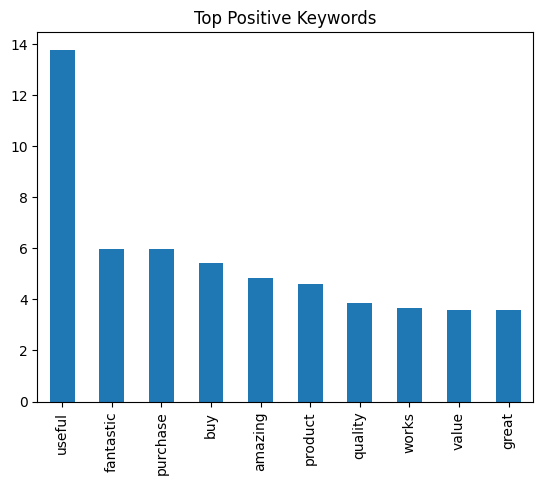

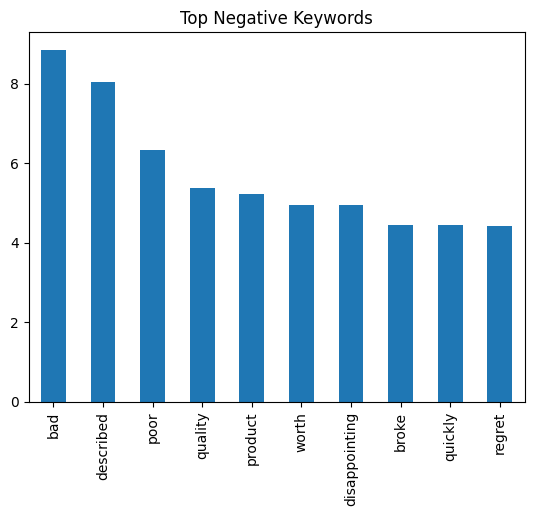

In [40]:
top_positive.plot(kind='bar')
plt.title("Top Positive Keywords")
plt.show()

top_negative.plot(kind='bar')
plt.title("Top Negative Keywords")
plt.show()

In [41]:
from wordcloud import WordCloud
# Function to generate word cloud for each sentiment
def generate_word_cloud(sentiment):
 SelectedOne=df[df['sentiment']==sentiment]
 text = ' '.join(str(review) for review in SelectedOne['review'])
 wordcloud = WordCloud(width=800, height=400,background_color='white',stopwords='english',colormap='viridis').generate(text)

 plt.figure(figsize=(10, 5))
 plt.imshow(wordcloud, interpolation='bilinear')
 plt.title('Word Cloud for '+ sentiment+ ' Reviews')
 plt.axis('off')
 plt.show()

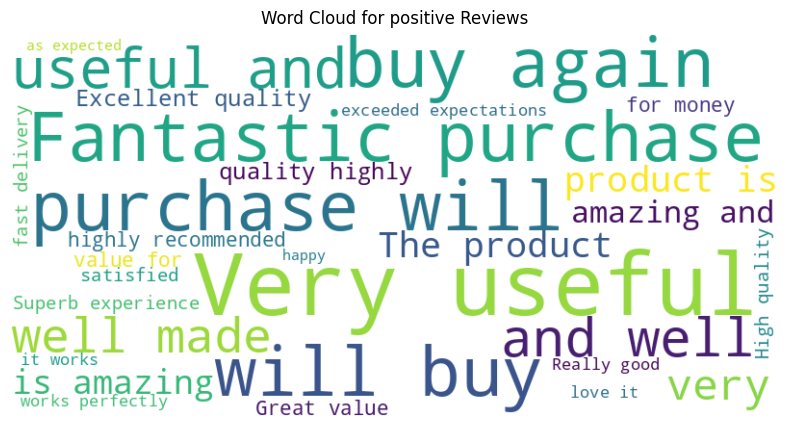

In [42]:
generate_word_cloud('positive')

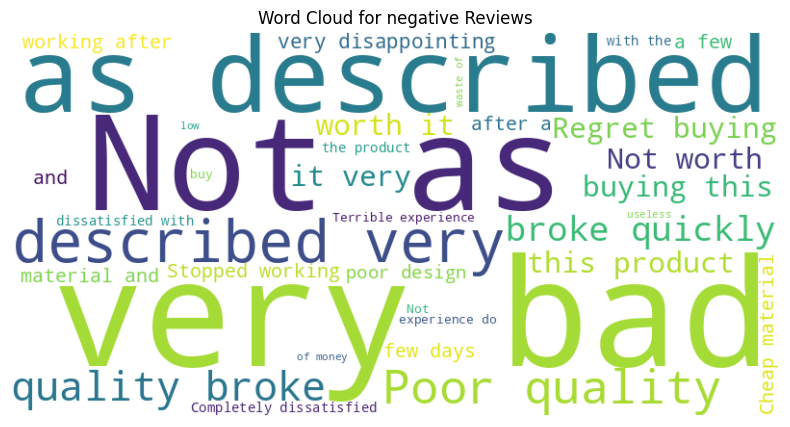

In [43]:
generate_word_cloud('negative')